In this Notebook, we want to create empirical Derrida plots. These are plots that relate the current normalised Hamming distance between two initial configurations (horizontal axis) to the normalised Hamming distance of those configurations in the next time step (vertical axis). If the resulting data point in the scatter plot is above the first diagonal, the Hamming distance is increasing (the damage is spreading). Otherwise, the damage remains the same, or even shrinks. Especially interesting is the behaviour around the origin, which is a measure for the sensitivity to initial conditions. The slope of the linear fit through the first couple of points close to the origin is called the Derrida coefficient.

IMPORTANT: the Derrida coefficient is related to the slope, but is not EQUAL to the slope! See for example "On Creativity of Elementary Cellular Automata" by Adamatzky et al. Try to read and understand the original Derrida paper ("Evolution of overlaps between con gurations in random Boolean networks")

In this notebook we will
1. [CHECK] Define a function that creates two pairs of arrays that can be used to plot the Derrida plot
2. [CHECK] Define a function that can use these arrays to output a single Derrida coefficient
3. [CHECK] Define a function that can output the equivalent rule for isomorphically defined LLNAs, and use this function to create a subset of non-equivalent rules.
4. [CHECK] For all non-equivalent rules of a particular resolution, and for a particular network, create a plot that relates the Derrida coefficient with genotype parameters (Hamming weight and Boolean sensitivity). Note that we should only run over non-equivalent rules.
    - The hope is that the Boolean sensitivity will correlate with the Derrida coefficient. [It does, almost perfectly]
5. For a number of particularly interesting rules, consider the influence of a network parameter on the Derrida coefficient.
    - We expect to see a sort of phase change when a particular average neighbourhood size is reached.

Remaining questions and further research topics are listed below:
- Can we make an analytical approximation of the Derrida plot and/or coordinate?
- What is the relationship with the Jacobian and other established methods?
- How does the Derrida coefficient relate to the mu sensitivity (which is not the same as the Boolean sensitivity after all)
- I should add the possiblity of choosing the order of the nodes that are being affected by the defect! In that way, I can compare what happens to the overall behaviour if you change states in nodes with high PageRank (for example) first, compared to low PageRank first. Right now, random nodes are being chosen every time.
- Perhaps I could make a Derrida plot counterpart for networks, where I look at the evolution of the size of the affected subgraph (?)
- Instead of the slope of the linear fit, I could look at the angle (0 to 90) and normalise it to 0 to 1. Not sure how useful that would be, though.
- I should compare the Derrida coefficient with (at least) the Shannon entropy, the word length distribution (calculated on whole diagram), and the Lempel-Ziv complexity.
- I should probably double-check for with ECAs (some seem a bit odd)

# 1. Function that creates the Derrida arrays

First load some modules and functions

In [27]:
# standard preamble for the Notebooks I use

import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *
from src.analysis import binary_indices, return_equivalent_rule, get_derrida_arrays, calculate_derrida_coefficient, boolean_sens, hamming_weight

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Make a very simple LLNA and visualise it in the usual fashion.

(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $R_{3}B_{2}S_{5}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

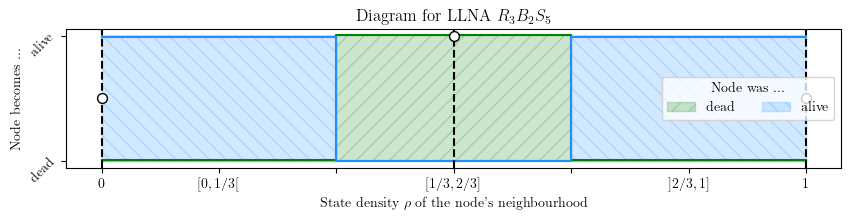

In [39]:
resolution = 3
born_if = [1]
survive_if = [0,2]
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)
# model = LLNA(resolution, iso=True)
model.diagram(degree=2, plot_dist=True)

Now calculate the arrays required to make the Derrida plot

In [40]:
# make a single ring graph and its edges
num_nodes = 1001  # Number of nodes
ring_graph = ig.Graph.Ring(num_nodes)
# edges
ring_graph.to_directed()
edges = tc.tensor(ring_graph.get_edgelist()).T
ring_graph.to_undirected()

# create 25 data points for each value of rho_t
points_per_rho = 5
num_init_configs = 5
init_configs = np.random.randint(0,2,size=(num_init_configs,num_nodes))
return_until_dens = 1

inputs, outputs = get_derrida_arrays(
    ring_graph,
    model,
    points_per_rho=points_per_rho,
    num_init_configs=None,
    init_configs=init_configs, 
    return_until_dens=return_until_dens
)

Create a Derrida plot, and show it alongside the spacetime diagrams and the defect propagation (as a sanity check). Note that these results should coincide exactly with the 36 non-equivalent outer-totalistic ECAs.

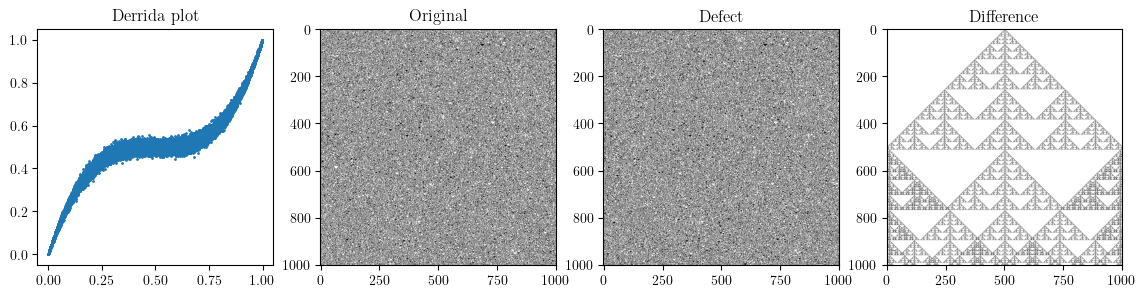

In [41]:
# find original TEP
H = np.array(model.forward(edges, tc.tensor(init_configs), T=num_nodes-1), dtype=int)

# find TEP from defected initial configuration
halfway_idx = init_configs.shape[-1]//2
init_configs_defect = init_configs.copy()
init_configs_defect[:,halfway_idx] = 1 - init_configs_defect[:,halfway_idx]

# find TEP from defect initial configuration
H_defect = np.array(model.forward(edges, tc.tensor(init_configs_defect), T=num_nodes-1), dtype=int)
# find difference pattern
H_difference = (H + H_defect) % 2

# plot
fig, axs = plt.subplots(1,4,figsize=(14,6))

example_idx = 0
axs[0].scatter(inputs, outputs, alpha=1, s=1)
axs[1].imshow(H[example_idx], cmap='Greys')
axs[2].imshow(H_defect[example_idx], cmap='Greys')
axs[3].imshow(H_difference[example_idx], cmap='Greys')

axs[0].set_title('Derrida plot')
axs[1].set_title('Original')
axs[2].set_title('Defect')
axs[3].set_title('Difference')

axs[0].set_xlim([-0.05, 1.05])
axs[0].set_ylim([-0.05, 1.05])
for ax in axs: ax.set_aspect(1)

Does this make sense? Better check this for correspondence with ECAs! It looks like it should be wrong.
- R3B2S4
- B : [1], S : [2]: 
111 110 101 100 011 010 001 000
 1   0   0   1   0   0   1   0 = 2 + 16 + 128 = 146 (seems legit so far)

100%|██████████| 1/1 [00:00<00:00, 32.38it/s]


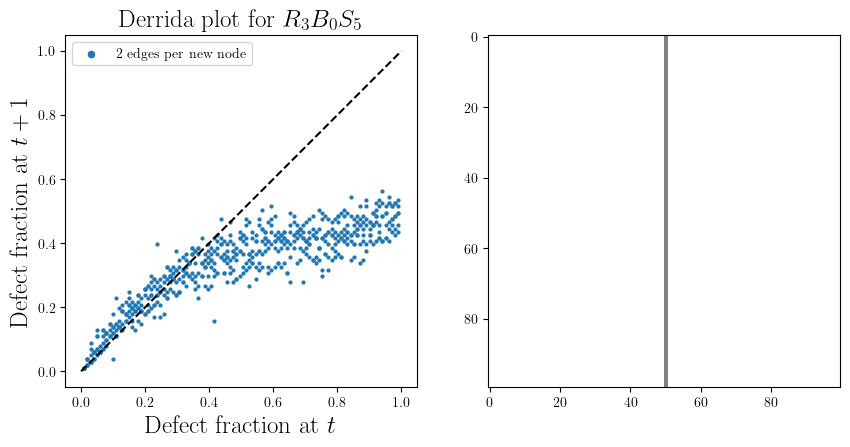

In [23]:
points_per_rho = 2
num_init_configs = 3

num_nodes = 101  # Number of nodes
num_edges_per_new_node_list = [2] #, 4, 6, 8, 10]  # Number of edges each new node adds
ring_graph = ig.Graph.Ring(num_nodes)
return_until_dens = 1.0

# init_config = np.zeros(num_nodes)
init_configs = np.random.randint(0, 2, size=(num_init_configs, num_nodes))

inputs_list = []
outputs_list = []
for num_edges_per_new_node in tqdm(num_edges_per_new_node_list, total=len(num_edges_per_new_node_list)):
    # Generate Scale-Free Network (Barabási–Albert Model)
    # ba_graph = ig.Graph.Barabasi(n=num_nodes, m=num_edges_per_new_node, directed=False)
    inputs, outputs = get_derrida_arrays(ring_graph, model, points_per_rho=points_per_rho, init_configs=init_configs, return_until_dens=return_until_dens)
    inputs_list.append(inputs)
    outputs_list.append(outputs)

# find TEP for comparison
ring_graph.to_directed()
edges = tc.tensor(ring_graph.get_edgelist()).T
ring_graph.to_undirected()
H = np.array(model.forward(edges, tc.tensor(init_configs), T=num_nodes-1), dtype=int)

edge_def_idx = 50
init_configs_def = init_configs.copy()
init_configs_def[:,edge_def_idx] = 1-init_configs_def[:,edge_def_idx]
H_def = np.array(model.forward(edges, tc.tensor(init_configs_def), T=num_nodes-1), dtype=int)

# figure
fig, axs = plt.subplots(1,2,figsize=(10,5))
fontsize=18
alpha=1
markersize=4
axs[0].plot([0, 1], [0, 1], 'k--')
for inputs, outputs, num_edges_per_new_node in zip(inputs_list, outputs_list, num_edges_per_new_node_list):
    axs[0].scatter(inputs, outputs, alpha=alpha, s=markersize, label=fr"{num_edges_per_new_node} edges per new node")

axs[0].set_title(fr"Derrida plot for {model.__str__(latex=True)}", fontsize=fontsize)
axs[0].set_xlabel(fr"Defect fraction at $t$", fontsize=fontsize)
axs[0].set_ylabel(fr"Defect fraction at $t+1$", fontsize=fontsize)

legend = axs[0].legend()
for handle in legend.legend_handles:
    handle.set_alpha(1)  # Set marker transparency in legend
    handle.set_sizes([20])  # Change marker size in legend

axs[0].set_aspect(1)
axs[0].set_xlim([-0.05, 1.05])
axs[0].set_ylim([-0.05, 1.05])

# show cropped version of TEP
# axs[1].imshow(H[0, :edge_def_idx*2, :edge_def_idx*2])
axs[1].imshow((H[0, :edge_def_idx*2, :edge_def_idx*2] + H_def[0, :edge_def_idx*2, :edge_def_idx*2]) % 2, cmap='Greys', alpha=0.5)


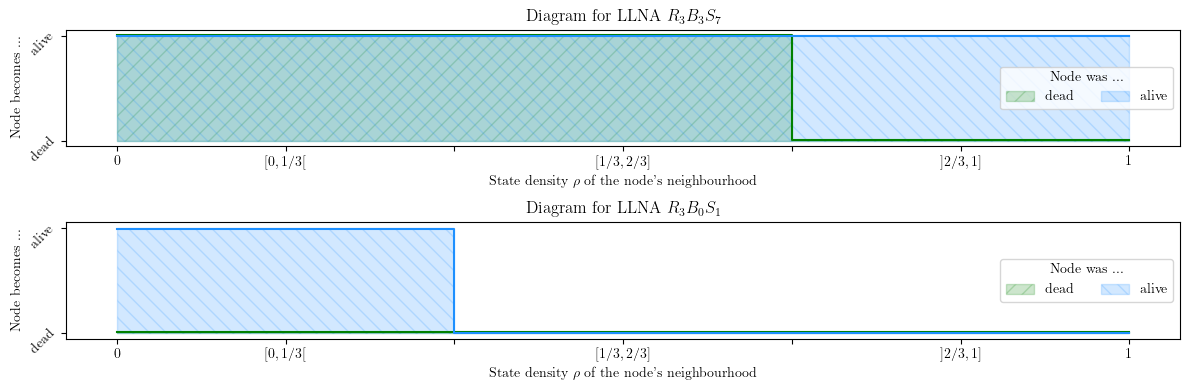

In [24]:
resolution = 3
model = LLNA(resolution, iso=True)
B_set, S_set = model.rule

B_set_equiv, S_set_equiv = return_equivalent_rule(resolution, B_set, S_set)
model_equiv = LLNA(resolution, x=B_set_equiv, y=S_set_equiv, iso=True)

fig, axs = plt.subplots(2,1, figsize=(12,4))
model.diagram(ax=axs[0])
model_equiv.diagram(ax=axs[1])

fig.tight_layout()

In [25]:
betas = range(2**resolution)
sigmas = range(2**resolution)

nonequiv_rules = []
equiv_rules = []
for beta in betas:
    born_if = binary_indices(beta)
    for sigma in sigmas:
        survive_if = binary_indices(sigma)
        if (beta, sigma) not in equiv_rules:
            nonequiv_rules.append((beta, sigma))
        beta_equiv, sigma_equiv = return_equivalent_rule(resolution, born_if, survive_if, return_decimals=True)
        equiv_rules.append((beta_equiv, sigma_equiv))
len(nonequiv_rules)

36

100%|██████████| 36/36 [01:21<00:00,  2.27s/it]


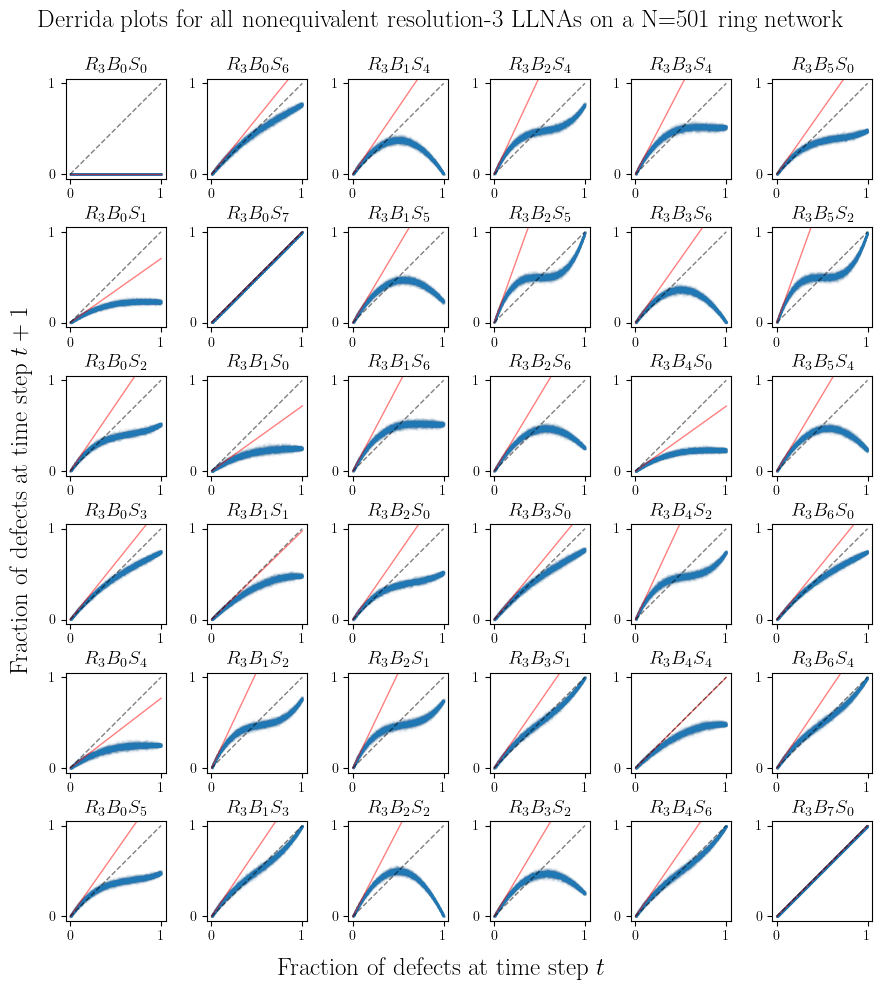

In [28]:
### NOTE: making this image takes a while

RUN_AGAIN = True

if RUN_AGAIN:
    # make network
    num_nodes = 501
    ring_graph = ig.Graph.Ring(num_nodes)

    # make initial condition
    n_init_configs = 5
    init_configs = np.random.randint(0, 2, size=(n_init_configs, num_nodes))

    # make figure
    fig, axs = plt.subplots(6,6,figsize=(9,10))
    fontsize=14
    alpha=0.01
    markersize=2

    points_per_rho = 5
    return_until_dens = 1

    inputs_list = []
    outputs_list = []
    derrida_coefficients = []
    # create derrida array
    for idx, (beta, sigma) in tqdm(enumerate(nonequiv_rules), total=len(nonequiv_rules)):
        # make model
        born_if = binary_indices(beta)
        survive_if = binary_indices(sigma)
        model = LLNA(resolution, born_if, survive_if, iso=True)
        # calculate derrida arrays and coefficients
        inputs, outputs = get_derrida_arrays(ring_graph, model, points_per_rho=points_per_rho, init_configs=init_configs, return_until_dens=return_until_dens)
        derrida_coefficient = calculate_derrida_coefficient(inputs, outputs)
        # save to lists
        inputs_list.append(inputs)
        outputs_list.append(outputs)
        derrida_coefficients.append(derrida_coefficient)
        # plot
        idx_h = idx % 6
        idx_v = idx // 6
        axs[idx_h,idx_v].scatter(inputs, outputs, alpha=alpha, s=markersize)
        axs[idx_h,idx_v].plot([0,1], [0, derrida_coefficient], color='r', lw=1, alpha=0.5)
        axs[idx_h,idx_v].set_title(fr"{model.__str__(latex=True)}", fontsize=fontsize)

    for ax_row in axs:
        for ax in ax_row:
            ax.plot([0,1], [0,1], color='k', ls='--', lw=1, alpha=0.5)
            ax.set_xlim([-0.05, 1.05])
            ax.set_ylim([-0.05, 1.05])
            ax.set_xticks([0,1])
            ax.set_yticks([0,1])
            ax.set_xticklabels([0,1])
            ax.set_yticklabels([0,1])
            ax.set_aspect(1)

    fig.suptitle(f"Derrida plots for all nonequivalent resolution-3 LLNAs on a N={num_nodes} ring network", fontsize=fontsize+4)
    fig.supxlabel(fr"Fraction of defects at time step $t$", fontsize=fontsize+4)
    fig.supylabel(fr"Fraction of defects at time step $t+1$", fontsize=fontsize+4)

    fig.tight_layout(rect=(0, 0, 1, 0.98))

    # plt.savefig("derrida_plots-nonequiv_outertotalistic_CAs.pdf")

In [ ]:
        inputs, outputs = get_derrida_arrays(ring_graph, model, points_per_rho=points_per_rho, init_configs=init_configs, return_until_dens=return_until_dens)
        derrida_coefficient = calculate_derrida_coefficient(inputs, outputs)
        # save to lists
        inputs_list.append(inputs)
        outputs_list.append(outputs)
        derrida_coefficients.append(derrida_coefficient)

100%|██████████| 36/36 [00:00<00:00, 97.79it/s] 


Text(0.5, 0.98, 'All nonequivalent resolution-3 LLNAs on a ring network')

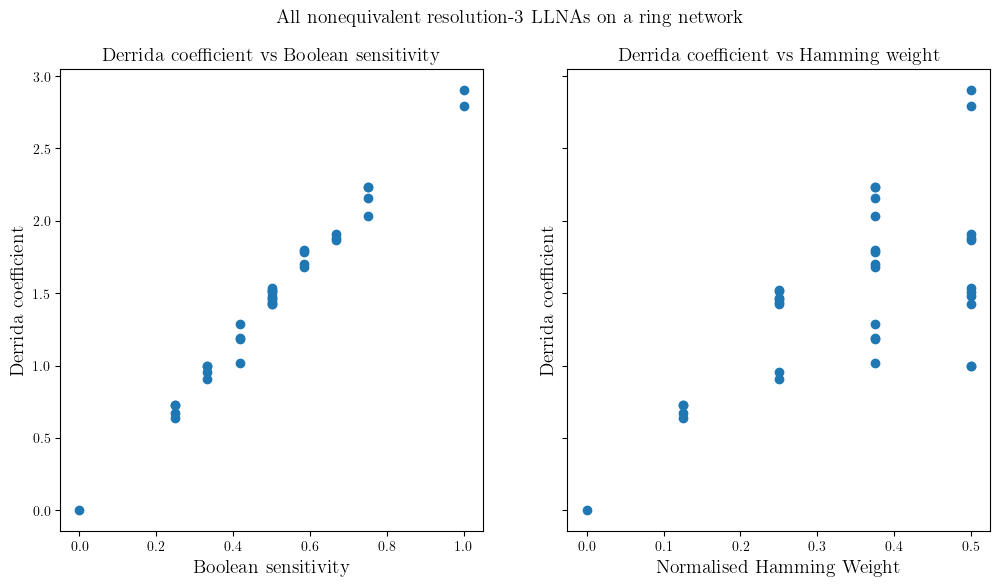

In [36]:
derrida_coefficients = []
BSs = []
HWs = []
points_per_rho = 5
num_init_configs = 5
return_until_dens = 0.06
for idx, (beta, sigma) in tqdm(enumerate(nonequiv_rules), total=len(nonequiv_rules)):
    # make model and get Derrida coefficients
    born_if = binary_indices(beta)
    survive_if = binary_indices(sigma)
    model = LLNA(resolution, born_if, survive_if, iso=True)
    inputs, outputs = get_derrida_arrays(ring_graph, model, points_per_rho=points_per_rho, num_init_configs=num_init_configs, return_until_dens=return_until_dens)
    derrida_coefficient = calculate_derrida_coefficient(inputs, outputs)
    derrida_coefficients.append(derrida_coefficient)
    # find BS and HW for simple ring network
    degree=2
    BS = boolean_sens(resolution, born_if, survive_if, degree)
    HW = hamming_weight(resolution, born_if, survive_if, degree)
    BSs.append(BS)
    HWs.append(HW)
HWs = np.array([HWs])
HWs[HWs>0.5] = 1-HWs[HWs>0.5]

fig, axs = plt.subplots(1,2,figsize=(12,6), sharey=True)
fontsize=14

axs[0].scatter(BSs, derrida_coefficients)
axs[1].scatter(HWs, derrida_coefficients)

axs[0].set_xlabel("Boolean sensitivity", fontsize=fontsize)
axs[0].set_ylabel("Derrida coefficient", fontsize=fontsize)
axs[0].set_title("Derrida coefficient vs Boolean sensitivity", fontsize=fontsize)

axs[1].set_xlabel("Normalised Hamming Weight", fontsize=fontsize)
axs[1].set_ylabel("Derrida coefficient", fontsize=fontsize)
axs[1].set_title("Derrida coefficient vs Hamming weight", fontsize=fontsize)

fig.suptitle("All nonequivalent resolution-3 LLNAs on a ring network", fontsize=fontsize)

Interesting! For ECAs, there is an almost one-to-one correlation between the Boolean sensivity and the Derrida coefficient. **why does that make sense**?